
# Deep Learning Architectures





## Part A - Multilayer Perceptron (MLP)



### Import Libraries


In [14]:
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten
import matplotlib.pyplot as plt

### Load the Dataset


In [15]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test = x_test / 255.0

### Build the Model

In [16]:
model = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128, activation='relu'),
    Dense(10, activation='softmax')
])

###Compile

In [17]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

###Train

In [18]:
history = model.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.9200 - loss: 0.2815 - val_accuracy: 0.9578 - val_loss: 0.1455
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9633 - loss: 0.1247 - val_accuracy: 0.9688 - val_loss: 0.1085
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9749 - loss: 0.0850 - val_accuracy: 0.9701 - val_loss: 0.1006
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9811 - loss: 0.0630 - val_accuracy: 0.9747 - val_loss: 0.0844
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9857 - loss: 0.0479 - val_accuracy: 0.9745 - val_loss: 0.0823
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9889 - loss: 0.0375 - val_accuracy: 0.9725 - val_loss: 0.0900
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.9901 - loss: 0.0306 - val_accuracy: 0.9738 - val_loss: 0.0877
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.9929 - loss: 0.0239 -

### Evaluate

In [19]:
test_loss, test_acc = model.evaluate(x_test, y_test)

print("Test Accuracy:", test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0838
Test Accuracy: 0.9779000282287598


### Plot Accuracy

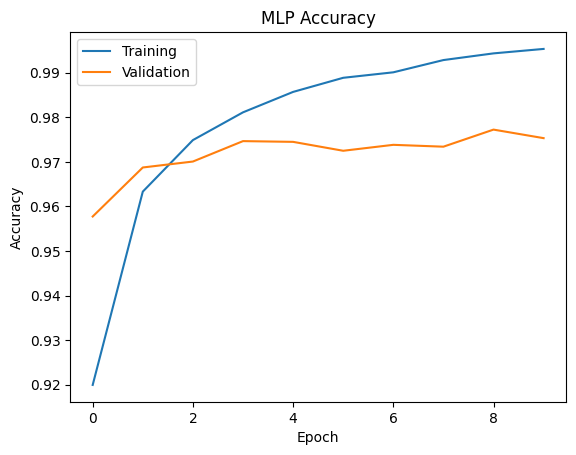

In [20]:
plt.plot(history.history['accuracy'], label='Training')
plt.plot(history.history['val_accuracy'], label='Validation')
plt.title("MLP Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

### Plot Loss

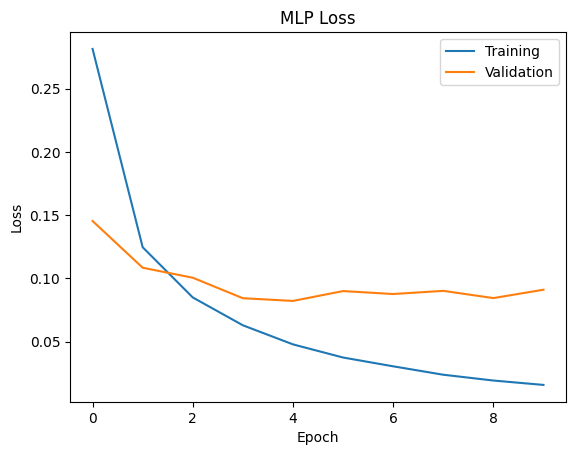

In [21]:
plt.plot(history.history['loss'], label='Training')
plt.plot(history.history['val_loss'], label='Validation')
plt.title("MLP Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

### Part B - CNN

### Import

In [22]:
from tensorflow.keras.datasets import cifar10
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense
from tensorflow.keras.models import Sequential

### Load Dataset

In [ ]:
(x_train,y_train),(x_test,y_test)=cifar10.load_data()

x_train=x_train/255.0
x_test=x_test/255.0

 52207616/170498071 ━━━━━━━━━━━━━━━━━━━━ 36:23 18us/step

### Create CNN

In [ ]:
cnn=Sequential([
    Conv2D(32,(3,3),activation='relu',input_shape=(32,32,3)),
    MaxPooling2D((2,2)),

    Conv2D(64,(3,3),activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),

    Dense(64,activation='relu'),

    Dense(10,activation='softmax')
])

### Compile

In [ ]:
cnn.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

### Train

history=cnn.fit(
    x_train,
    y_train,
    epochs=10,
    validation_split=0.2
)

### Evaluate

In [ ]:
loss,acc=cnn.evaluate(x_test,y_test)

print(acc)

### Confusion Matrix

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import numpy as np

pred=np.argmax(cnn.predict(x_test),axis=1)

cm=confusion_matrix(y_test,pred)

sns.heatmap(cm,annot=True,fmt="d")
plt.title("Confusion Matrix")
plt.show()

### Correct Predictions

In [ ]:
correct=np.where(pred==y_test.flatten())[0]

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_test[correct[i]])
    plt.title(pred[correct[i]])
    plt.axis("off")

plt.show()

### Incorrect Predictions

wrong=np.where(pred!=y_test.flatten())[0]

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(x_test[wrong[i]])
    plt.title(f"P:{pred[wrong[i]]} A:{y_test[wrong[i]][0]}")
    plt.axis("off")

plt.show()

### Part C - RNN (IMDB Reviews)

In [ ]:
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences

(x_train,y_train),(x_test,y_test)=imdb.load_data(num_words=10000)

x_train=pad_sequences(x_train,maxlen=200)
x_test=pad_sequences(x_test,maxlen=200)

### Build LSTM

In [ ]:
from tensorflow.keras.layers import Embedding,LSTM,Dense

model=Sequential([
    Embedding(10000,64,input_length=200),
    LSTM(64),
    Dense(1,activation='sigmoid')
])

### Compile

In [ ]:
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

### Train

In [ ]:
history=model.fit(
    x_train,
    y_train,
    epochs=5,
    validation_split=0.2
)

### Evaluate

In [ ]:
loss,acc=model.evaluate(x_test,y_test)

print(acc)

### Plot

In [ ]:
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Training","Validation"])
plt.title("RNN Accuracy")
plt.show()

### Part E Reflection

The CNN was the most effective architecture for its task of image classification because convolutional layers are designed to detect visual features such as edges, textures, and shapes. The MLP also performed well on the handwritten digit classification task, but it was not as effective at capturing spatial information. The LSTM successfully learned relationships between words in movie reviews, allowing it to classify sentiment with good accuracy.

The biggest challenge during this project was determining the right number of training epochs without overfitting the models. It also took some time to understand the differences between each neural network architecture and how they are designed for different types of data.

These deep learning models have many practical applications in the real world. CNNs are commonly used for handwriting recognition, medical image analysis, facial recognition, and self-driving vehicles. LSTMs are useful for sentiment analysis, language translation, speech recognition, and text prediction, while MLPs can be applied to a variety of general classification problems.